In [1]:
!ls

sample_data  train.csv.zip


**Task 1**: *Domain Understanding & Data Collection*

Understood retail KPIs such as sales trends and seasonality. Collected dataset from open sources and loaded it using pandas for analysis.

In [2]:
!unzip train.csv.zip

Archive:  train.csv.zip
   creating: train.csv/
  inflating: train.csv/holidays_events.csv  
  inflating: train.csv/oil.csv       
  inflating: train.csv/sample_submission.csv  
  inflating: train.csv/stores.csv    
  inflating: train.csv/test.csv      
  inflating: train.csv/train.csv     
  inflating: train.csv/transactions.csv  


 **Task 2**: *Exploratory Data Analysis (EDA)*

Cleaned the dataset by handling missing values and outliers. Visualized sales trends, seasonal patterns, and holiday impacts using plots.

In [4]:
import zipfile

with zipfile.ZipFile("train.csv.zip", 'r') as zip_ref:
    zip_ref.extractall("data")

In [6]:
import pandas as pd

df = pd.read_csv("data/train.csv/train.csv")
df.head()

,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0


In [7]:
df.shape

(3000888, 6)

In [8]:
df.columns

Index(['id', 'date', 'store_nbr', 'family', 'sales', 'onpromotion'], dtype='object')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 6 columns):
 #   Column       Dtype  
---  ------       -----  
 0   id           int64  
 1   date         object 
 2   store_nbr    int64  
 3   family       object 
 4   sales        float64
 5   onpromotion  int64  
dtypes: float64(1), int64(3), object(2)
memory usage: 137.4+ MB


In [10]:
df.describe()

,id,store_nbr,sales,onpromotion
count,3.000888e+06,3.000888e+06,3.000888e+06,3.000888e+06
mean,1.500444e+06,2.750000e+01,3.577757e+02,2.602770e+00
std,8.662819e+05,1.558579e+01,1.101998e+03,1.221888e+01
min,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00
25%,7.502218e+05,1.400000e+01,0.000000e+00,0.000000e+00
50%,1.500444e+06,2.750000e+01,1.100000e+01,0.000000e+00
75%,2.250665e+06,4.100000e+01,1.958473e+02,0.000000e+00
max,3.000887e+06,5.400000e+01,1.247170e+05,7.410000e+02


In [11]:
df.isnull().sum()

,0
id,0
date,0
store_nbr,0
family,0
sales,0
onpromotion,0


In [12]:
df.fillna(df.mean(numeric_only=True), inplace=True)

In [13]:
df.dropna(inplace=True)

In [14]:
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date')

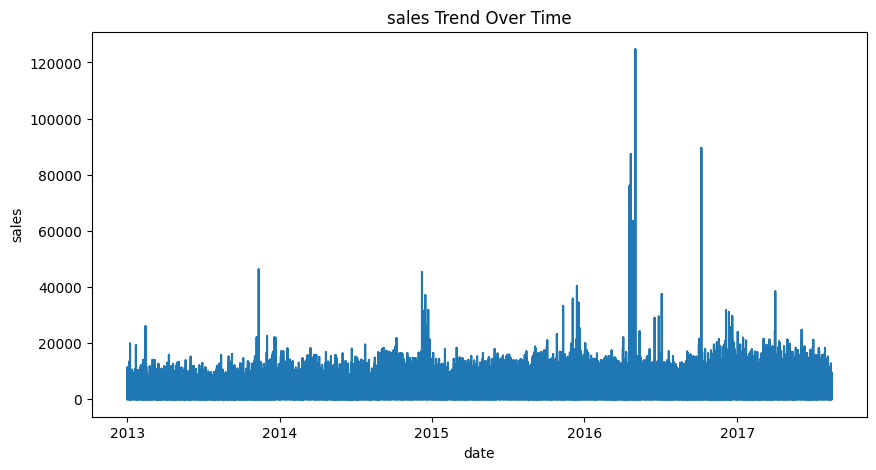

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(df['date'], df['sales'])
plt.title("sales Trend Over Time")
plt.xlabel("date")
plt.ylabel("sales")
plt.show()

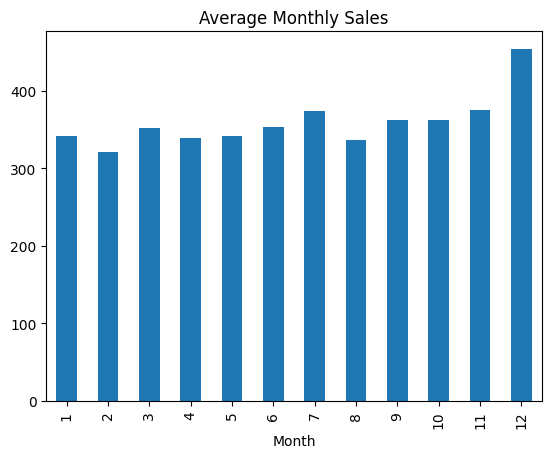

In [16]:
df['Month'] = df['date'].dt.month
monthly_sales = df.groupby('Month')['sales'].mean()

monthly_sales.plot(kind='bar')
plt.title("Average Monthly Sales")
plt.show()

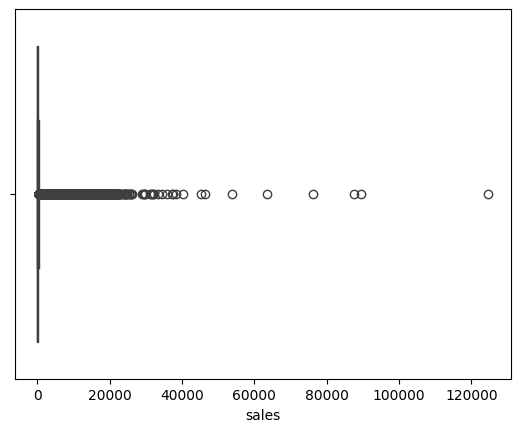

In [17]:
import seaborn as sns

sns.boxplot(x=df['sales'])
plt.show()

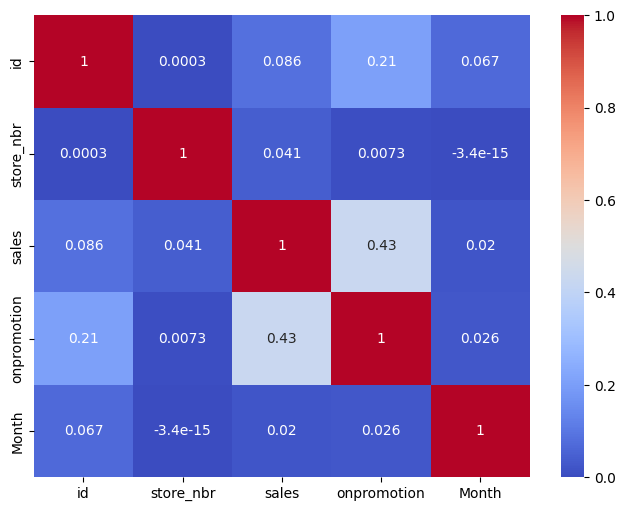

In [18]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

In [19]:
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date')

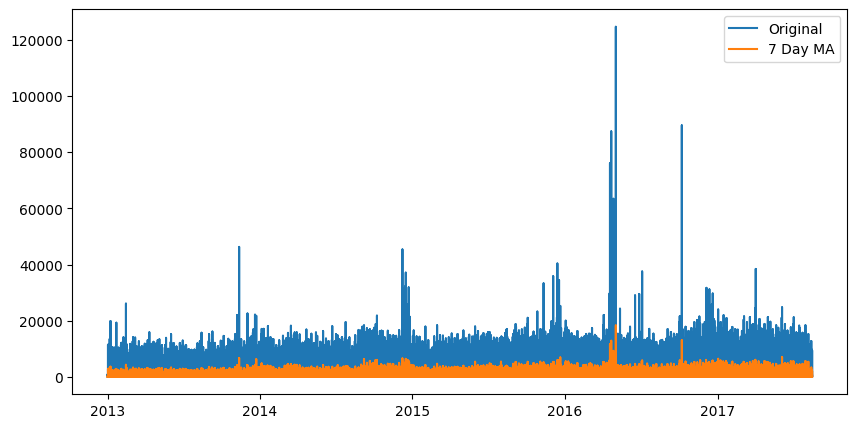

In [20]:
df['7_day_MA'] = df['sales'].rolling(window=7).mean()

plt.figure(figsize=(10,5))
plt.plot(df['date'], df['sales'], label='Original')
plt.plot(df['date'], df['7_day_MA'], label='7 Day MA')
plt.legend()
plt.show()

In [21]:
df.to_csv("updated_train.csv", index=False)

**Task 3**: *Feature Engineering*

Created new features like lag values, rolling averages, and promotion indicators. Encoded categorical variables and analyzed correlations.

In [22]:
import os
print(os.listdir())

['.config', 'train.csv', 'train.csv.zip', 'data', 'updated_train.csv', 'sample_data']


In [23]:
import pandas as pd

df = pd.read_csv("train.csv/train.csv")

df['date'] = pd.to_datetime(df['date'])

df.head()

,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0


In [24]:
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day
df['weekday'] = df['date'].dt.weekday
df['weekofyear'] = df['date'].dt.isocalendar().week

In [25]:
df['lag_1'] = df['sales'].shift(1)
df['lag_7'] = df['sales'].shift(7)

In [26]:
df['rolling_mean_7'] = df['sales'].rolling(window=7).mean()
df['rolling_mean_30'] = df['sales'].rolling(window=30).mean()

In [27]:
print(df.columns)

Index(['id', 'date', 'store_nbr', 'family', 'sales', 'onpromotion', 'year',
       'month', 'day', 'weekday', 'weekofyear', 'lag_1', 'lag_7',
       'rolling_mean_7', 'rolling_mean_30'],
      dtype='object')


In [28]:
from sklearn.preprocessing import LabelEncoder

le_family = LabelEncoder()
df['family'] = le_family.fit_transform(df['family'])

df.head()

,id,date,store_nbr,family,sales,onpromotion,year,month,day,weekday,weekofyear,lag_1,lag_7,rolling_mean_7,rolling_mean_30
0,0,2013-01-01,1,0,0.0,0,2013,1,1,1,1,NaN,NaN,NaN,NaN
1,1,2013-01-01,1,1,0.0,0,2013,1,1,1,1,0.0,NaN,NaN,NaN
2,2,2013-01-01,1,2,0.0,0,2013,1,1,1,1,0.0,NaN,NaN,NaN
3,3,2013-01-01,1,3,0.0,0,2013,1,1,1,1,0.0,NaN,NaN,NaN
4,4,2013-01-01,1,4,0.0,0,2013,1,1,1,1,0.0,NaN,NaN,NaN


In [29]:
df['onpromotion'] = df['onpromotion'].astype(int)

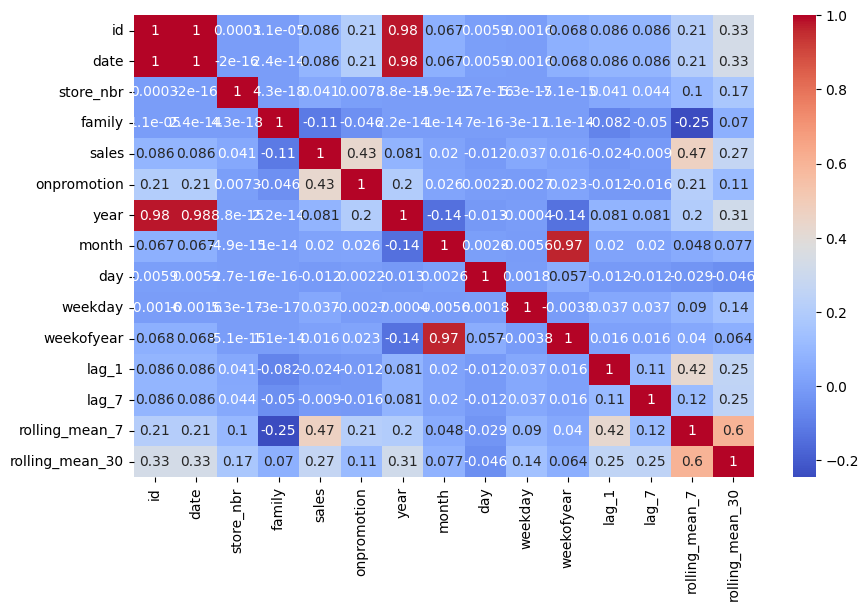

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df.corr()

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

In [31]:
df.to_csv("feature_engineered_sales.csv", index=False)

**Task 4**: *Machine Learning Models*

Trained models like Linear Regression, Random Forest, and XGBoost. Evaluated performance using MAE, RMSE, and R² score.

In [32]:
df = df.dropna()

In [33]:
X = df.drop(['sales', 'date', 'id'], axis=1)
y = df['sales']

In [34]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [35]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [36]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred_lr)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2 = r2_score(y_test, y_pred_lr)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 408.32176731159365
RMSE: 865.2523209405606
R2 Score: 0.37816858224272143


**Task 5**: *Time Series Models*

Performed stationarity check and built ARIMA/SARIMA models. Compared results with ML models to select the best approach.

In [39]:
import pandas as pd

# Convert date
df['date'] = pd.to_datetime(df['date'])

# Sort data
df = df.sort_values('date')

# Create time series (group by date)
df_ts = df.groupby('date')['sales'].sum().reset_index()

# Set date as index
df_ts.set_index('date', inplace=True)

df_ts.head()

,sales
date,
2013-01-01,2511.618999
2013-01-02,496092.417944
2013-01-03,361461.231124
2013-01-04,354459.677093
2013-01-05,477350.121229


In [40]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df_ts['sales'])

print("ADF Statistic:", result[0])
print("p-value:", result[1])

if result[1] < 0.05:
    print("Data is Stationary ✅")
else:
    print("Data is NOT Stationary ❌ (Use differencing)")

ADF Statistic: -2.6161957486048544
p-value: 0.08969592175787511
Data is NOT Stationary ❌ (Use differencing)


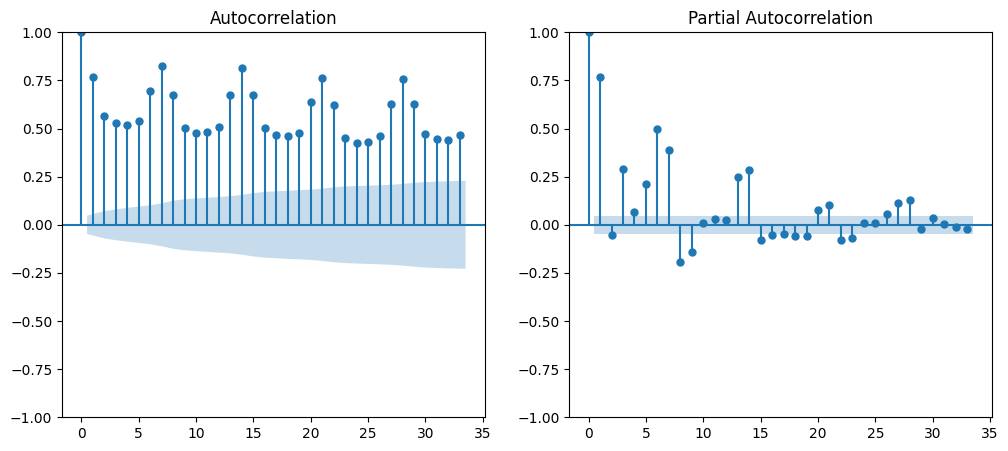

In [41]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plot_acf(df_ts['sales'], ax=plt.gca())

plt.subplot(1,2,2)
plot_pacf(df_ts['sales'], ax=plt.gca())

plt.show()

In [42]:
from statsmodels.tsa.arima.model import ARIMA

# Example order (you can tune)
model_arima = ARIMA(df_ts['sales'], order=(1,1,1))
model_arima_fit = model_arima.fit()

print(model_arima_fit.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                  sales   No. Observations:                 1684
Model:                 ARIMA(1, 1, 1)   Log Likelihood              -22336.996
Date:                Tue, 14 Apr 2026   AIC                          44679.992
Time:                        09:09:26   BIC                          44696.277
Sample:                             0   HQIC                         44686.024
                               - 1684                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4419      0.018     24.285      0.000       0.406       0.478
ma.L1         -0.9609      0.008   -124.779      0.000      -0.976      -0.946
sigma2      2.467e+10   1.53e-13   1.62e+23      0.0

In [43]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

model_sarima = SARIMAX(df_ts['sales'],
                      order=(1,1,1),
                      seasonal_order=(1,1,1,12))  # 12 = monthly seasonality

model_sarima_fit = model_sarima.fit()

print(model_sarima_fit.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                      
Dep. Variable:                              sales   No. Observations:                 1684
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood              -22603.319
Date:                            Tue, 14 Apr 2026   AIC                          45216.638
Time:                                    09:09:53   BIC                          45243.744
Sample:                                         0   HQIC                         45226.682
                                           - 1684                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4685      0.052      8.963      0.000       0.366       0.571
ma.L1         -0.9416      0.032   

In [44]:
forecast_arima = model_arima_fit.forecast(steps=30)
forecast_sarima = model_sarima_fit.forecast(steps=30)

print("ARIMA Forecast:\n", forecast_arima)
print("SARIMA Forecast:\n", forecast_sarima)

ARIMA Forecast:
 1684    804625.851705
1685    823169.368190
1686    831363.598812
1687    834984.563345
1688    836584.638415
1689    837291.698706
1690    837604.142955
1691    837742.209552
1692    837803.220070
1693    837830.180127
1694    837842.093559
1695    837847.358008
1696    837849.684326
1697    837850.712307
1698    837851.166564
1699    837851.367296
1700    837851.455998
1701    837851.495195
1702    837851.512516
1703    837851.520170
1704    837851.523552
1705    837851.525046
1706    837851.525707
1707    837851.525999
1708    837851.526128
1709    837851.526185
1710    837851.526210
1711    837851.526221
1712    837851.526226
1713    837851.526228
Name: predicted_mean, dtype: float64
SARIMA Forecast:
 1684    784455.588150
1685    761983.324233
1686    777159.332213
1687    855529.548816
1688    854096.782014
1689    854153.447571
1690    880207.115014
1691    857661.262360
1692    841309.131840
1693    817878.000140
1694    855774.094024
1695    871170.826036
1696

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


In [47]:
from sklearn.ensemble import RandomForestRegressor

# Take smaller sample (very important)
X_train_small = X_train.sample(5000, random_state=42)
y_train_small = y_train.loc[X_train_small.index]

rf = RandomForestRegressor(
    n_estimators=10,   # reduce trees
    max_depth=10,      # limit depth
    n_jobs=-1,         # use all CPU cores
    random_state=42
)

rf.fit(X_train_small, y_train_small)

y_pred_rf = rf.predict(X_test)

In [48]:
from sklearn.metrics import mean_absolute_error

mae_rf = mean_absolute_error(y_test, y_pred_rf)

print("Random Forest MAE:", mae_rf)

Random Forest MAE: 142.53102575734155


**Task 6**:* Sales Forecasting*

Predicted future sales for the next 30 days and generated confidence intervals.

In [49]:
import pandas as pd

# Convert date
df['date'] = pd.to_datetime(df['date'])

# Group by date
df_ts = df.groupby('date')['sales'].sum()

df_ts.head()

,sales
date,
2013-01-01,2511.618999
2013-01-02,496092.417944
2013-01-03,361461.231124
2013-01-04,354459.677093
2013-01-05,477350.121229


In [50]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(df_ts, order=(1,1,1))  # simple model

model_fit = model.fit()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [51]:
forecast = model_fit.forecast(steps=30)

print(forecast)

1684    804625.851705
1685    823169.368190
1686    831363.598812
1687    834984.563345
1688    836584.638415
1689    837291.698706
1690    837604.142955
1691    837742.209552
1692    837803.220070
1693    837830.180127
1694    837842.093559
1695    837847.358008
1696    837849.684326
1697    837850.712307
1698    837851.166564
1699    837851.367296
1700    837851.455998
1701    837851.495195
1702    837851.512516
1703    837851.520170
1704    837851.523552
1705    837851.525046
1706    837851.525707
1707    837851.525999
1708    837851.526128
1709    837851.526185
1710    837851.526210
1711    837851.526221
1712    837851.526226
1713    837851.526228
Name: predicted_mean, dtype: float64


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [52]:
# Create future dates
future_dates = pd.date_range(start=df_ts.index[-1], periods=31)[1:]

# Create forecast dataframe
forecast_df = pd.DataFrame({
    'Date': future_dates,
    'Predicted_Sales': forecast
})

forecast_df.head()

,Date,Predicted_Sales
1684,2017-08-16,804625.851705
1685,2017-08-17,823169.368190
1686,2017-08-18,831363.598812
1687,2017-08-19,834984.563345
1688,2017-08-20,836584.638415


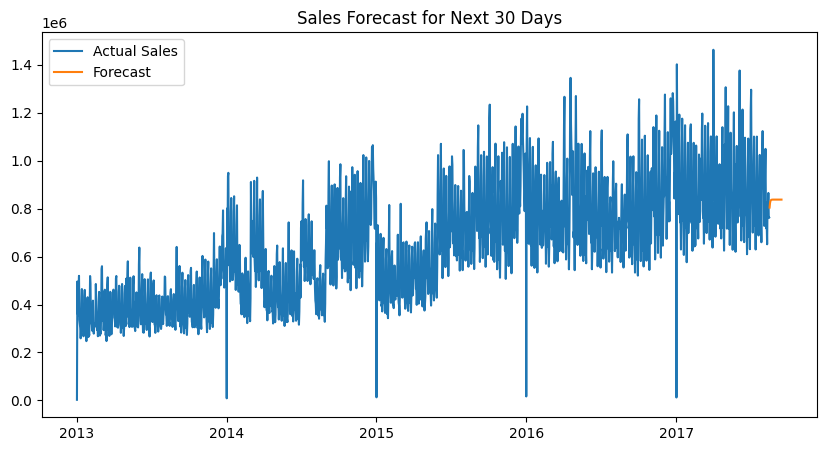

In [53]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(df_ts.index, df_ts, label='Actual Sales')
plt.plot(forecast_df['Date'], forecast_df['Predicted_Sales'], label='Forecast')

plt.legend()
plt.title("Sales Forecast for Next 30 Days")

plt.show()

**Task 7**: *Visualization & Reporting*

Visualized actual vs predicted sales and exported results into CSV/Excel format.

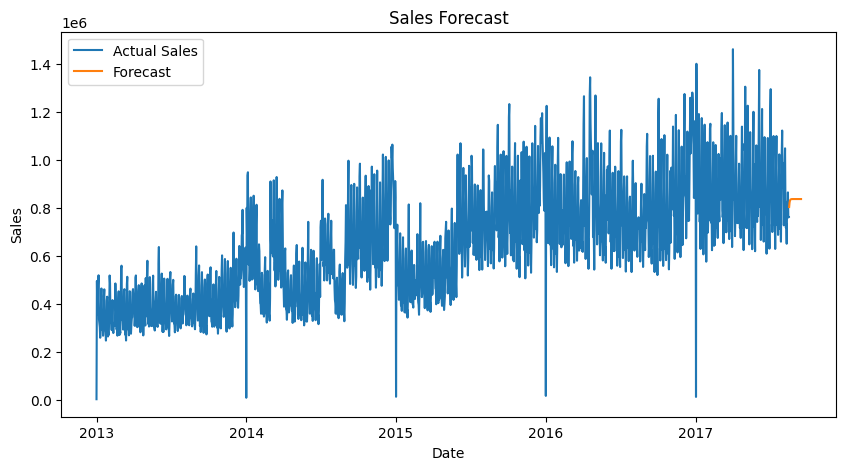

In [54]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

# Actual vs Forecast
plt.plot(df_ts.index, df_ts, label='Actual Sales')
plt.plot(forecast_df['Date'], forecast_df['Predicted_Sales'], label='Forecast')

plt.legend()
plt.title("Sales Forecast")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.show()

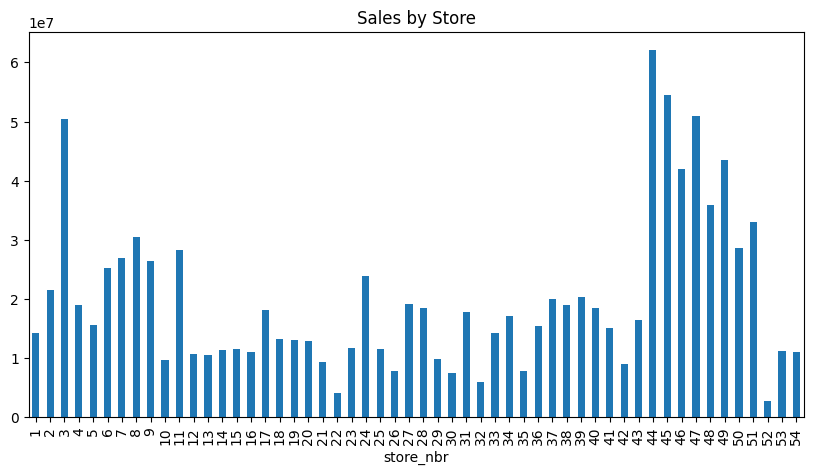

In [55]:
# Group by store
store_sales = df.groupby('store_nbr')['sales'].sum()

store_sales.plot(kind='bar', figsize=(10,5), title="Sales by Store")

plt.show()

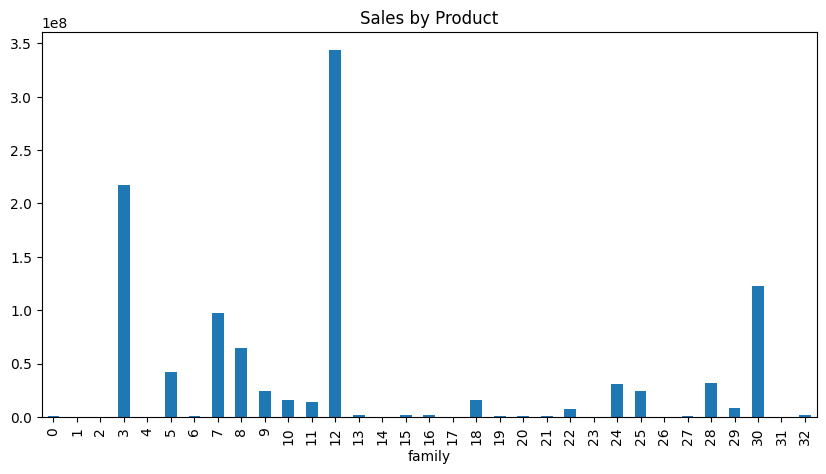

In [56]:
# Group by product
family_sales = df.groupby('family')['sales'].sum()

family_sales.plot(kind='bar', figsize=(10,5), title="Sales by Product")

plt.show()

In [57]:
import plotly.express as px

fig = px.line(forecast_df, x='Date', y='Predicted_Sales',
              title="Forecasted Sales (Next 30 Days)")

fig.show()

In [58]:
# Save forecast
forecast_df.to_csv("forecast_report.csv", index=False)

In [60]:
# Save only first 10000 rows
df_sample = df.head(10000)

with pd.ExcelWriter("sales_report.xlsx") as writer:
    df_sample.to_excel(writer, sheet_name='Raw Data', index=False)
    forecast_df.to_excel(writer, sheet_name='Forecast', index=False)